In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


In [5]:
from typing import TypedDict

class State(TypedDict):
    graph_state: str

## Nodes

In [11]:


def mood(state: State) -> State:
    print("--Mood--")
    return {"graph_state": state["graph_state"] + " I am"}


def happy(state: State) -> State:
    print("--Happy--")
    return {"graph_state": state["graph_state"] + " happy"}


def sad(state: State) -> State:
    print("--Sad--")
    return {"graph_state": state["graph_state"] + " sad"}

## Edges

In [12]:
import random
from typing import Literal

def decide_mood(state: State) -> Literal["happy", "sad"]:
    print("--Decide Mood--")
    user_input = state["graph_state"]
    print(f"User input: {user_input}")
    return random.choice(["happy", "sad"])

## Graph Construction

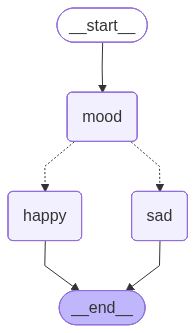

In [13]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("mood", mood)
builder.add_node("happy", happy)
builder.add_node("sad", sad)

builder.add_edge(START, "mood")
builder.add_conditional_edges("mood", decide_mood)
builder.add_edge("happy", END)
builder.add_edge("sad", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Graph Invocation

In [17]:
graph.invoke({"graph_state": "Hello!, I'm Saroj."})

--Mood--
--Decide Mood--
User input: Hello!, I'm Saroj. I am
--Sad--


{'graph_state': "Hello!, I'm Saroj. I am sad"}